# Real Estate Pricing Factor Dynamics

Explore the trend, volatility, cycles, deal noise and shock components discussed in Chapter 5 of {cite}`farevuu2018`. These are illustrative market scenarios, not calibrated forecasts.

## Goal
Construct reproducible market paths, inspect their components and replay them from captured inputs. The recorded Model contains the plan, sampled parameters, innovations and realized paths.

## Setup

In [1]:
%matplotlib inline
from datetime import date
from uuid import uuid4
import os, sys
import pandas as pd  # Detached tables for presentation only.
import matplotlib.pyplot as plt
import rangekeeper as rk
from rangekeeper.examples import investment
from rangekeeper.io import MemoryStore
from rangekeeper.execution import Executor
from rangekeeper.run import validate
from rangekeeper.adapters.plotting import plot_flows, plot_distribution, plot_pairs
from rangekeeper.calculations import series
from rangekeeper.model import Model, Metadata
from rangekeeper.model.flow import Flow, Movement
from rangekeeper.duration import make_periods
from rangekeeper.model.distribution import Distribution
from rangekeeper.scenarios import market, replay
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.prop_cycle': plt.cycler(color=['#285f8f','#cf8b2e','#9c557a','#627c49','#737373'])})
print('Installed package:', rk.__file__)
assert not {'rangekeeper.flux','rangekeeper.dynamics','rangekeeper.policy','rangekeeper._legacy_duration'} & set(sys.modules)

Installed package: /private/tmp/rk-naming-wheel-verified/site/rangekeeper/__init__.py


## Steps
### 1. Declare the plan
The space cycle multiplies the volatile rental level. The asset cycle is subtracted from the mean capitalization rate, so a positive cycle raises values. Noise multiplies true value. Shock amplitude is applied once.

Trend, Volatility, Cyclicality, Noise and Black Swan constructors declare inputs only. Cycle amplitudes are half the full height. The stored space-cycle variation is centred on zero; its multiplier is one plus that variation.

In [2]:
periods = make_periods(date(2021, 1, 1), frequency='year', count=26)
base_model = Model.create(metadata=Metadata(id=uuid4(), schema_version='0.5.0'))
plan = market.make_plan(periods=periods, seed=20261006, components=(
    market.make_trend(initial_value=.05, growth_rate=.02, cap_rate=.05),
    market.make_volatility(volatility_per_period=.04, autoregression=.2, mean_reversion=.15),
    market.make_cyclicality(space_period=12., space_phase=2., space_amplitude=.25,
                           asset_period=13., asset_phase=3., asset_amplitude=.01),
    market.make_noise(lower=-.04, upper=.04),
    market.make_black_swan(likelihood=.03, impact=-.25, dissipation=.5),
))

### 2. Generate one named realization

In [3]:
scenario = market.generate(base_model, plan, scenario_keys=['market-example'])[0]
print('Scenario:', scenario.realization.key, 'Seed:', plan.seed, 'Generator:', scenario.realization.generator)
pd.DataFrame([{'Library': item.name, 'Version': item.version} for item in scenario.realization.versions])

Scenario: market-example Seed: 20261006 Generator: numpy.SeedSequence/PCG64


,Library,Version
0,python,3.10.19
1,numpy,2.2.6
2,scipy,1.15.3


### 3. Inspect trend and accumulating volatility

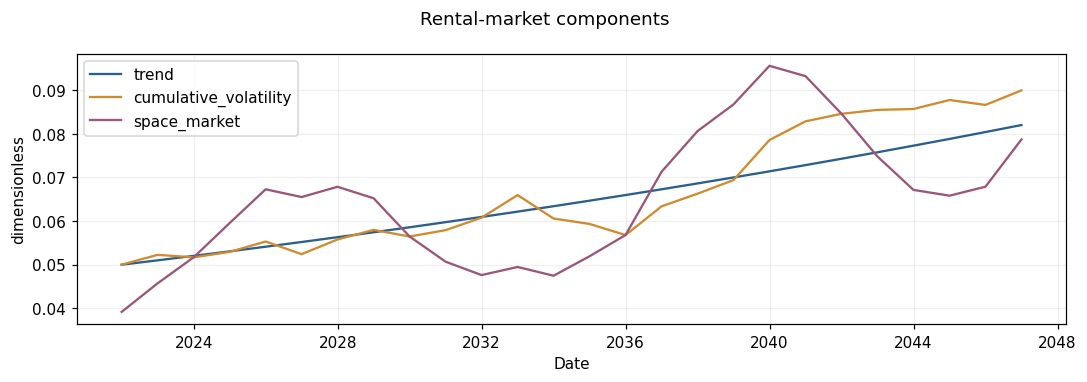

In [4]:
plot_flows({name: scenario.resolve_output(name).flow for name in ('trend','cumulative_volatility','space_market')}, title='Rental-market components');

### 4. Inspect the space and asset cycles
These dimensionless cycles have different amplitudes. Their exact parameters remain in the recorded plan.

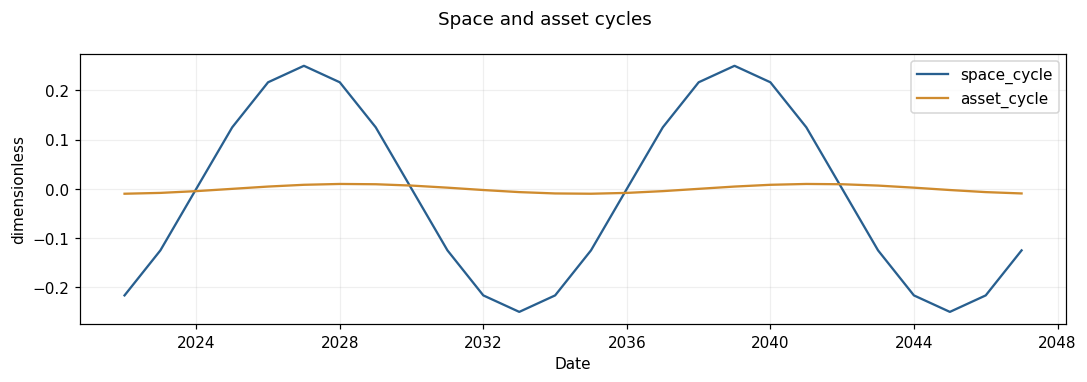

In [5]:
plot_flows({name: scenario.resolve_output(name).flow for name in ('space_cycle','asset_cycle')}, title='Space and asset cycles');

### 5. Inspect noise and shocks

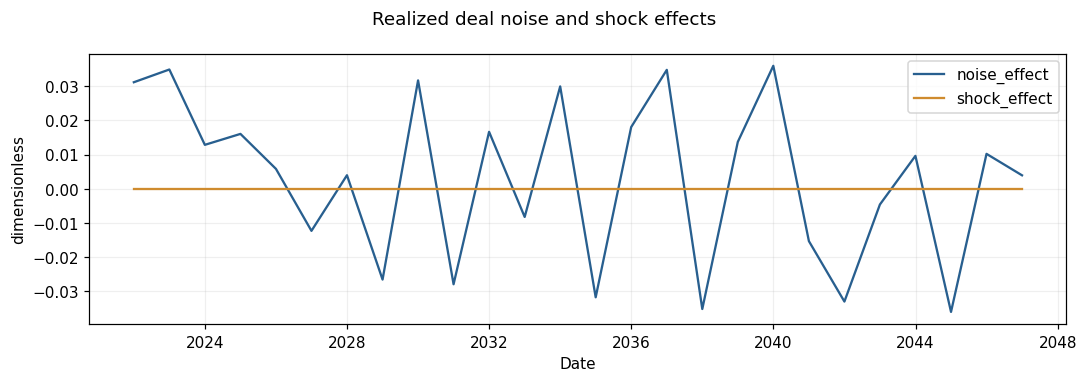

In [6]:
plot_flows({name: scenario.resolve_output(name).flow for name in ('noise_effect','shock_effect')}, title='Realized deal noise and shock effects');

### 6. Inspect market value paths

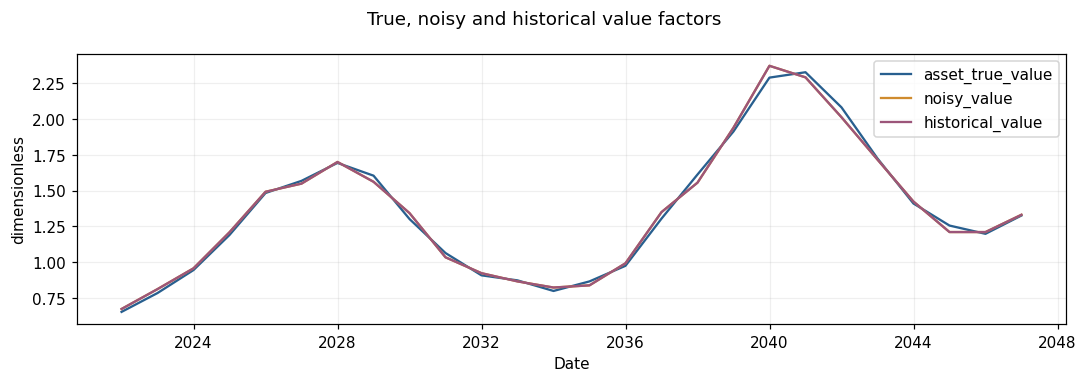

In [7]:
plot_flows({name: scenario.resolve_output(name).flow for name in ('asset_true_value','noisy_value','historical_value')}, title='True, noisy and historical value factors');

### 7. Inspect investment inputs and availability
Pricing factors can scale unit-bearing rental Flows. Implied reversion capitalization is next-period rent divided by current historical value. It and forward returns become available only at the following period end.

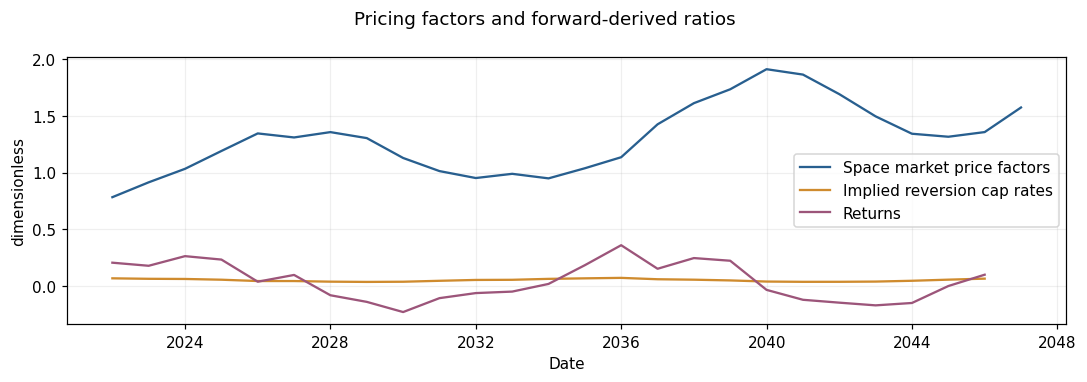

In [8]:
plot_flows({'Space market price factors': scenario.space_market_price_factors.flow, 'Implied reversion cap rates': scenario.implied_reversion_cap_rates.flow, 'Returns': scenario.returns.flow}, title='Pricing factors and forward-derived ratios');

In [9]:
pd.DataFrame([{'Target Value': str(a.target.value), 'Movement': a.target.movement, 'Available': a.available_at} for a in scenario.realization.availability if a.target.value == scenario.implied_reversion_cap_rates.id]).head(6)

,Target Value,Movement,Available
0,b50afc27-4297-5ece-9aa7-659a62a6e095,p1,2022-12-31
1,b50afc27-4297-5ece-9aa7-659a62a6e095,p2,2023-12-31
2,b50afc27-4297-5ece-9aa7-659a62a6e095,p3,2024-12-31
3,b50afc27-4297-5ece-9aa7-659a62a6e095,p4,2025-12-31
4,b50afc27-4297-5ece-9aa7-659a62a6e095,p5,2026-12-31
5,b50afc27-4297-5ece-9aa7-659a62a6e095,p6,2027-12-31


## Checks

In [10]:
replayed = replay(scenario.model)
assert replayed.model.id == scenario.model.id
assert replayed.model.to_data() == scenario.model.to_data()
print('Captured-input replay matches all recorded paths.')

Captured-input replay matches all recorded paths.


In [11]:
assert not {'rangekeeper.flux','rangekeeper.dynamics','rangekeeper.policy','rangekeeper._legacy_duration'} & set(sys.modules)
print('Canonical records, explicit roles and installed consumer checks passed.')

Canonical records, explicit roles and installed consumer checks passed.


## Next Steps
Use these same realized paths for both fixed-horizon and policy-controlled investment comparisons. Do not expose forward-derived ratios to an earlier decision.